# Local Invertibility is Not Global Invertibility

Deep dive on `03c_20x20_opposite` - the canonical case where the 2-triangle constraint SLSQP succeeds with `neg_TR = 0` but the warped field is still **not globally invertible**. Previously surfaced as one row in [03_demos.ipynb](03_demos.ipynb) Part 3; this notebook gives it the same treatment 05 and 07 give their hard cases.

The story:

1. **Run best-2tri SLSQP** (analytical Jacobian + warm-start) on `03c_20x20_opposite`. Converges with `success=True`, `neg_TR = 0`. Every cell is individually non-folded.
2. **Global quad self-intersection check** reports `QI > 0`. Two non-adjacent quads' edges still cross somewhere in the warped grid.
3. **Visualize where and why.** The 'opposite-motion' fold pattern pushes two regions of the grid against each other. Each cell at the collision front stays locally convex, but the *regions* overlap.
4. **Damping experiment.** Linearly interpolate between the identity and `phi_out` and scan `alpha`: how much of the correction can we apply before the global check starts failing?
5. **Next steps** discussion.

This is the counterexample that motivates an outer-loop global repulsion (option 1 from [03_demos.ipynb](03_demos.ipynb)'s 'next steps for global invertibility').

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint
from scipy.sparse import csr_matrix

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_areas2D
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_2d
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.jacobian.intersection import has_quad_self_intersections, _quads_intersect
from dvfopt.core.objective import objective_euc

from test_cases import make_deformation

THRESHOLD = DEFAULT_PARAMS['threshold']
print(f'threshold = {THRESHOLD}')

threshold = 0.01


In [2]:
def _forward_jdet_2d(dy, dx):
    ddx_dx = dx[:-1, 1:]  - dx[:-1, :-1]
    ddy_dy = dy[1:,  :-1] - dy[:-1, :-1]
    ddx_dy = dx[1:,  :-1] - dx[:-1, :-1]
    ddy_dx = dy[:-1, 1:]  - dy[:-1, :-1]
    return (1 + ddx_dx) * (1 + ddy_dy) - ddx_dy * ddy_dx

def measure(phi):
    jd = np.squeeze(jacobian_det2D(phi))
    fd = _forward_jdet_2d(phi[0], phi[1])
    tri = triangle_sign_areas2D(phi)
    return dict(jd=jd, fd=fd, tri=tri,
                n_cd=int((jd <= 0).sum()), n_fd=int((fd <= 0).sum()),
                n_tr=int((tri <= 0).sum()),
                min_cd=float(jd.min()), min_fd=float(fd.min()), min_tr=float(tri.min()))

def list_intersecting_quads(phi):
    dy, dx = phi[0], phi[1]
    H, W = dy.shape
    nr, nc = H - 1, W - 1
    if nr <= 0 or nc <= 0:
        return []
    rows = np.arange(H, dtype=float)[:, None]
    cols = np.arange(W, dtype=float)[None, :]
    Y = rows + dy; X = cols + dx
    y_tl, x_tl = Y[:-1, :-1], X[:-1, :-1]
    y_tr, x_tr = Y[:-1, 1:],  X[:-1, 1:]
    y_br, x_br = Y[1:,  1:],  X[1:,  1:]
    y_bl, x_bl = Y[1:,  :-1], X[1:,  :-1]
    ymin = np.minimum(np.minimum(y_tl, y_tr), np.minimum(y_bl, y_br)).ravel()
    ymax = np.maximum(np.maximum(y_tl, y_tr), np.maximum(y_bl, y_br)).ravel()
    xmin = np.minimum(np.minimum(x_tl, x_tr), np.minimum(x_bl, x_br)).ravel()
    xmax = np.maximum(np.maximum(x_tl, x_tr), np.maximum(x_bl, x_br)).ravel()
    corners = np.stack([
        np.stack([y_tl.ravel(), x_tl.ravel()], axis=1),
        np.stack([y_tr.ravel(), x_tr.ravel()], axis=1),
        np.stack([y_br.ravel(), x_br.ravel()], axis=1),
        np.stack([y_bl.ravel(), x_bl.ravel()], axis=1),
    ], axis=1)
    n_quads = nr * nc
    pairs = []
    for i in range(n_quads):
        ri, ci = divmod(i, nc)
        for j in range(i + 1, n_quads):
            rj, cj = divmod(j, nc)
            if abs(ri - rj) <= 1 and abs(ci - cj) <= 1: continue
            if (ymin[i] > ymax[j] or ymax[i] < ymin[j]
                    or xmin[i] > xmax[j] or xmax[i] < xmin[j]): continue
            if _quads_intersect(corners[i], corners[j]):
                pairs.append(((ri, ci), (rj, cj)))
    return pairs

In [3]:
def triangle_sign_constraint_jac_2d(dy, dx):
    H_, W_ = dy.shape
    nr, nc = H_ - 1, W_ - 1
    N = H_ * W_
    ref_y, ref_x = np.mgrid[:H_, :W_]
    X = ref_x + dx; Y = ref_y + dy
    TLx, TLy = X[:-1, :-1], Y[:-1, :-1]
    TRx, TRy = X[:-1, 1:],  Y[:-1, 1:]
    BLx, BLy = X[1:,  :-1], Y[1:,  :-1]
    BRx, BRy = X[1:,  1:],  Y[1:,  1:]
    cy_grid, cx_grid = np.mgrid[:nr, :nc]
    cy = cy_grid.ravel(); cx = cx_grid.ravel()
    def dx_idx(py, px): return py * W_ + px
    def dy_idx(py, px): return N + py * W_ + px
    n_cells = nr * nc
    T1_rows = np.tile(np.arange(n_cells), 6)
    T1_cols = np.concatenate([
        dx_idx(cy, cx + 1), dy_idx(cy, cx + 1),
        dx_idx(cy + 1, cx), dy_idx(cy + 1, cx),
        dx_idx(cy + 1, cx + 1), dy_idx(cy + 1, cx + 1),
    ])
    T1_vals = np.concatenate([
        0.5 * (BRy - BLy).ravel(), 0.5 * (BLx - BRx).ravel(),
        0.5 * (TRy - BRy).ravel(), 0.5 * (BRx - TRx).ravel(),
        0.5 * (BLy - TRy).ravel(), 0.5 * (TRx - BLx).ravel(),
    ])
    T2_rows = np.tile(np.arange(n_cells) + n_cells, 6)
    T2_cols = np.concatenate([
        dx_idx(cy, cx),     dy_idx(cy, cx),
        dx_idx(cy + 1, cx), dy_idx(cy + 1, cx),
        dx_idx(cy, cx + 1), dy_idx(cy, cx + 1),
    ])
    T2_vals = np.concatenate([
        0.5 * (TRy - BLy).ravel(), 0.5 * (BLx - TRx).ravel(),
        0.5 * (TLy - TRy).ravel(), 0.5 * (TRx - TLx).ravel(),
        0.5 * (BLy - TLy).ravel(), 0.5 * (TLx - BLx).ravel(),
    ])
    rows = np.concatenate([T1_rows, T2_rows])
    cols = np.concatenate([T1_cols, T2_cols])
    vals = np.concatenate([T1_vals, T2_vals])
    return csr_matrix((vals, (rows, cols)), shape=(2 * n_cells, 2 * N))

def run_2tri_best(phi_init, threshold=THRESHOLD, max_iter=500):
    _, H_, W_ = phi_init.shape
    pixels = H_ * W_
    def unpack(z):
        return z[pixels:].reshape(H_, W_), z[:pixels].reshape(H_, W_)
    def tri_flat(dy, dx):
        T1, T2 = _triangle_areas_2d(dy, dx)
        return np.concatenate([T1.flatten(), T2.flatten()])
    def tri_jac(z):
        dy, dx = unpack(z)
        return triangle_sign_constraint_jac_2d(dy, dx)
    z0 = np.concatenate([phi_init[1].flatten(), phi_init[0].flatten()])
    z0_init = z0.copy()
    t0 = time.time()
    res = minimize(lambda z: objective_euc(z, z0_init), z0,
                   jac=True, method='SLSQP',
                   constraints=[NonlinearConstraint(
                       lambda z: tri_flat(*unpack(z)), threshold, np.inf, jac=tri_jac)],
                   options={'maxiter': max_iter, 'disp': False})
    total_nit = res.nit; total_time = time.time() - t0
    if not res.success and res.status == 8:
        rng = np.random.default_rng(123)
        z_warm = res.x + rng.normal(scale=0.01, size=res.x.shape)
        t1 = time.time()
        res = minimize(lambda z: objective_euc(z, z0_init), z_warm,
                       jac=True, method='SLSQP',
                       constraints=[NonlinearConstraint(
                           lambda z: tri_flat(*unpack(z)), threshold, np.inf, jac=tri_jac)],
                       options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False})
        total_nit += res.nit; total_time += time.time() - t1
    dy_o, dx_o = unpack(res.x)
    phi_out = np.stack([dy_o, dx_o])
    m = measure(phi_out)
    m.update(phi=phi_out, nit=total_nit, time=total_time,
             success=bool(res.success), status=int(res.status),
             message=str(res.message),
             l2=float(np.linalg.norm(phi_out - phi_init)))
    return m

## Setup - load `03c_20x20_opposite`

Opposite-motion fold on a 20x20 grid. Two regions push against each other producing a characteristic collision front.

In [4]:
CASE_KEY = '03c_20x20_opposite'
deformation, *_ = make_deformation(CASE_KEY)
phi_init = np.stack([deformation[1, 0], deformation[2, 0]])
m0 = measure(phi_init)
qi0 = list_intersecting_quads(phi_init)
H_, W_ = phi_init[0].shape
print(f'{CASE_KEY}  shape=({H_}, {W_})  pixels={H_*W_}  vars={2*H_*W_}')
print(f'init  neg_CD={m0["n_cd"]:>3d}  neg_FD={m0["n_fd"]:>3d}  neg_TR={m0["n_tr"]:>3d}  QI={len(qi0):>3d}')
print(f'init  min_CD={m0["min_cd"]:+.3f}  min_FD={m0["min_fd"]:+.3f}  min_TR={m0["min_tr"]:+.3f}')

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


03c_20x20_opposite  shape=(20, 20)  pixels=400  vars=800
init  neg_CD= 34  neg_FD= 32  neg_TR= 58  QI= 57
init  min_CD=-1.432  min_FD=-1.619  min_TR=-0.809


## Pre-optimization fold structure

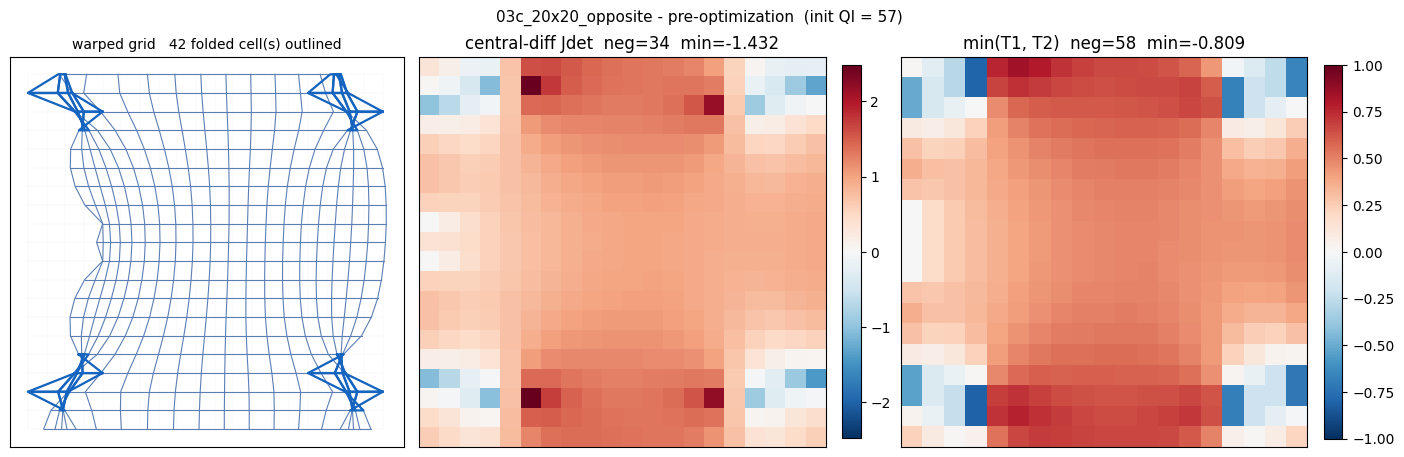

In [5]:
def plot_warped_grid(ax, phi, title, highlight_mask=None, fold_color='#1565c0'):
    dy = phi[0]; dx = phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f4f4f4', lw=0.3)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f4f4f4', lw=0.3)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.8)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.8)
    if highlight_mask is not None:
        for (cy, cx) in np.argwhere(highlight_mask):
            px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(px, py, color=fold_color, lw=1.6)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

tri_init = triangle_sign_areas2D(phi_init)
local_fold_mask_init = tri_init.min(axis=0) <= 0

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout='constrained')
plot_warped_grid(axes[0], phi_init,
                  f'warped grid   {int(local_fold_mask_init.sum())} folded cell(s) outlined',
                  highlight_mask=local_fold_mask_init)
vmax_cd = float(max(abs(m0['jd']).max(), 1.0))
im1 = axes[1].imshow(m0['jd'], cmap='RdBu_r', vmin=-vmax_cd, vmax=vmax_cd, aspect='auto')
axes[1].set_title(f"central-diff Jdet  neg={m0['n_cd']}  min={m0['min_cd']:+.3f}")
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
tri_min0 = tri_init.min(axis=0)
vmax_tr = float(max(abs(tri_min0).max(), 1.0))
im2 = axes[2].imshow(tri_min0, cmap='RdBu_r', vmin=-vmax_tr, vmax=vmax_tr, aspect='auto')
axes[2].set_title(f"min(T1, T2)  neg={m0['n_tr']}  min={m0['min_tr']:+.3f}")
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.suptitle(f'{CASE_KEY} - pre-optimization  (init QI = {len(qi0)})', fontsize=11)
plt.show()

## Run best 2-triangle SLSQP

Analytical Jacobian + perturbation warm-start. Converges locally. The question is what happens globally.

In [6]:
r = run_2tri_best(phi_init)
phi_out = r['phi']
qi_out = list_intersecting_quads(phi_out)
print(f"SLSQP:  nit={r['nit']}  time={r['time']:.2f}s  success={r['success']}  status={r['status']}")
print(f"        message: {r['message']}")
print()
print(f"  BEFORE   neg_TR={m0['n_tr']:>3d}   QI={len(qi0):>3d}")
print(f"  AFTER    neg_TR={r['n_tr']:>3d}   QI={len(qi_out):>3d}")
print()
print(f"  L2 from phi_init = {r['l2']:.3f}")
if r['n_tr'] == 0 and len(qi_out) > 0:
    print()
    print(f"  >>> LOCAL PASS, GLOBAL FAIL.  {len(qi_out)} non-adjacent quad pair(s) still cross.")

SLSQP:  nit=21  time=4.92s  success=True  status=0
        message: Optimization terminated successfully

  BEFORE   neg_TR= 58   QI= 57
  AFTER    neg_TR=  0   QI= 20

  L2 from phi_init = 4.733

  >>> LOCAL PASS, GLOBAL FAIL.  20 non-adjacent quad pair(s) still cross.


## Visualization: initial vs. after best 2-tri SLSQP

Row: warped grid + `min(T1, T2)` heatmap. Left column is initial; right column is the post-SLSQP result. The top row's warped grid outlines local 2-triangle folds in dark blue.

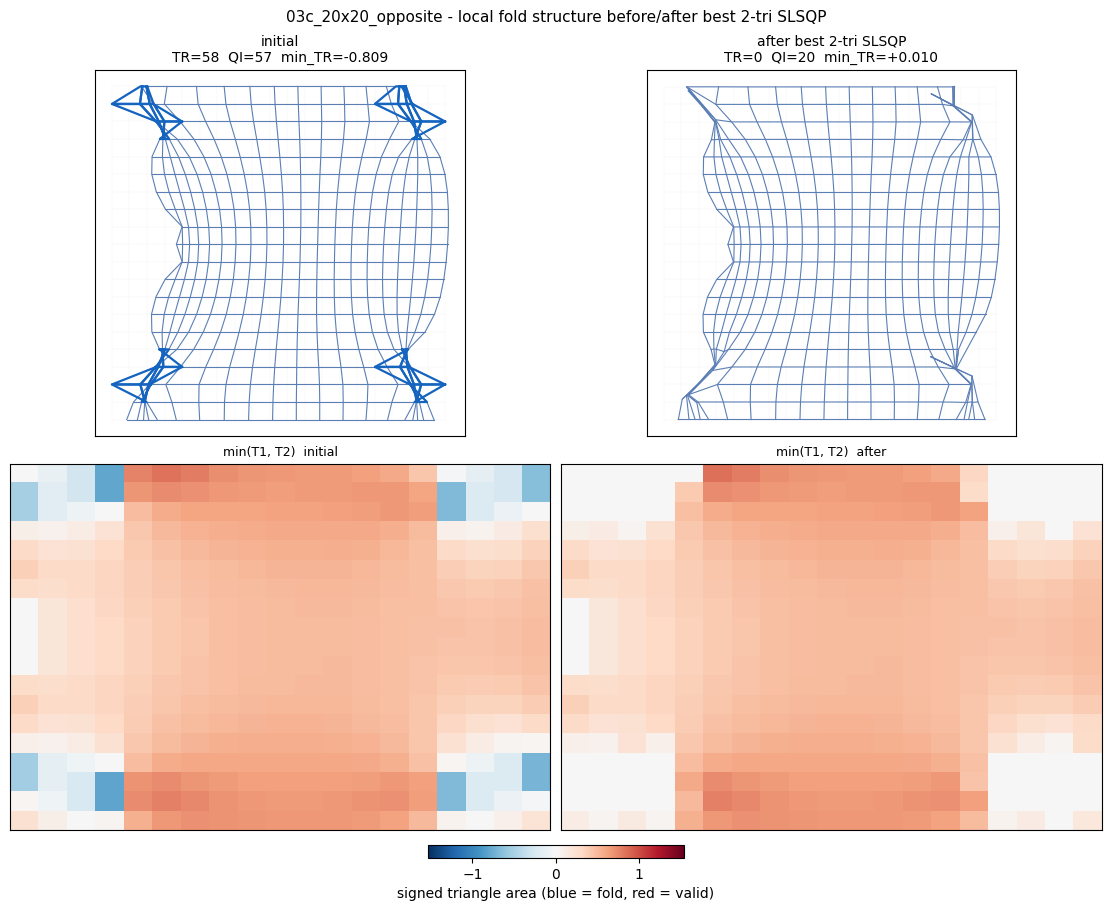

In [7]:
tri_after = r['tri']
local_fold_mask_after = tri_after.min(axis=0) <= 0

vmax_tri = max(abs(tri_init).max(), abs(tri_after).max())
NL = chr(10)

fig, axes = plt.subplots(2, 2, figsize=(11, 9), layout='constrained')

plot_warped_grid(axes[0, 0], phi_init,
                  'initial' + NL + f"TR={m0['n_tr']}  QI={len(qi0)}  min_TR={m0['min_tr']:+.3f}",
                  highlight_mask=local_fold_mask_init)
plot_warped_grid(axes[0, 1], phi_out,
                  'after best 2-tri SLSQP' + NL + f"TR={r['n_tr']}  QI={len(qi_out)}  min_TR={r['min_tr']:+.3f}",
                  highlight_mask=local_fold_mask_after)

tri0_min = tri_init.min(axis=0)
im1 = axes[1, 0].imshow(tri0_min, cmap='RdBu_r', vmin=-vmax_tri, vmax=vmax_tri, aspect='auto')
axes[1, 0].set_title(f"min(T1, T2)  initial", fontsize=9)
axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])
tri1_min = tri_after.min(axis=0)
im2 = axes[1, 1].imshow(tri1_min, cmap='RdBu_r', vmin=-vmax_tri, vmax=vmax_tri, aspect='auto')
axes[1, 1].set_title(f"min(T1, T2)  after", fontsize=9)
axes[1, 1].set_xticks([]); axes[1, 1].set_yticks([])
cbar = fig.colorbar(im2, ax=axes[1, :], orientation='horizontal',
                    fraction=0.035, pad=0.04, shrink=0.55)
cbar.set_label('signed triangle area (blue = fold, red = valid)')
plt.suptitle(f'{CASE_KEY} - local fold structure before/after best 2-tri SLSQP', fontsize=11)
plt.show()

## Global quad-intersection analysis

Even though `neg_TR = 0` after the SLSQP run, `QI > 0`. Every cell is locally convex, yet somewhere in the field two non-adjacent quads' edges cross. The sections below pinpoint where, show the pairs, and discuss why the 2-triangle constraint cannot prevent it.

In [8]:
# List the intersecting pairs and the cells involved.
print(f'{len(qi_out)} intersecting pair(s) after best 2-tri SLSQP:')
flagged_cells = set()
for (a, b) in qi_out:
    flagged_cells.add(a); flagged_cells.add(b)
print(f'  -> {len(flagged_cells)} distinct cell(s) involved')
print()
for i, (a, b) in enumerate(qi_out[:20]):
    print(f"  pair {i:>2d}:  cell {a}  <->  cell {b}")
if len(qi_out) > 20:
    print(f"  ... (+{len(qi_out) - 20} more)")

20 intersecting pair(s) after best 2-tri SLSQP:
  -> 16 distinct cell(s) involved

  pair  0:  cell (0, 13)  <->  cell (0, 18)
  pair  1:  cell (0, 13)  <->  cell (1, 18)
  pair  2:  cell (0, 14)  <->  cell (0, 18)
  pair  3:  cell (0, 14)  <->  cell (1, 18)
  pair  4:  cell (0, 15)  <->  cell (0, 18)
  pair  5:  cell (0, 15)  <->  cell (1, 18)
  pair  6:  cell (0, 16)  <->  cell (0, 18)
  pair  7:  cell (0, 16)  <->  cell (1, 18)
  pair  8:  cell (0, 18)  <->  cell (1, 16)
  pair  9:  cell (14, 18)  <->  cell (16, 17)
  pair 10:  cell (14, 18)  <->  cell (16, 18)
  pair 11:  cell (15, 13)  <->  cell (15, 18)
  pair 12:  cell (15, 13)  <->  cell (16, 18)
  pair 13:  cell (15, 14)  <->  cell (15, 18)
  pair 14:  cell (15, 14)  <->  cell (16, 18)
  pair 15:  cell (15, 15)  <->  cell (15, 18)
  pair 16:  cell (15, 15)  <->  cell (16, 18)
  pair 17:  cell (15, 16)  <->  cell (15, 18)
  pair 18:  cell (15, 16)  <->  cell (16, 18)
  pair 19:  cell (15, 18)  <->  cell (16, 16)


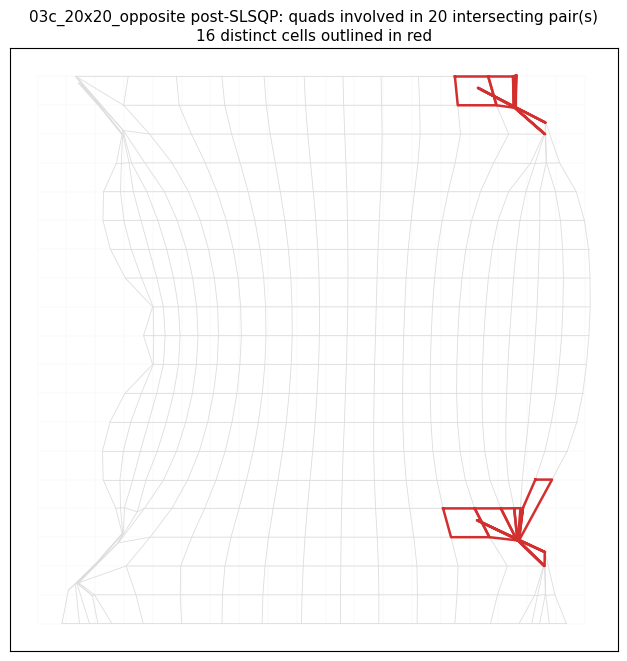

In [9]:
# Overlay the flagged quads on the warped grid.
phi = phi_out
Hh, Ww = phi[0].shape
yy, xx = np.mgrid[:Hh, :Ww]
gx = xx + phi[1]; gy = yy + phi[0]

fig, ax = plt.subplots(figsize=(10, 6.5), layout='constrained')
for i in range(Hh):
    ax.plot(xx[i], yy[i], color='#f4f4f4', lw=0.3)
for j in range(Ww):
    ax.plot(xx[:, j], yy[:, j], color='#f4f4f4', lw=0.3)
for i in range(Hh):
    ax.plot(gx[i], gy[i], color='#dddddd', lw=0.6)
for j in range(Ww):
    ax.plot(gx[:, j], gy[:, j], color='#dddddd', lw=0.6)
for (cy, cx) in flagged_cells:
    poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
    poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
    ax.plot(poly_x, poly_y, color='#d32f2f', lw=1.8)
ax.set_aspect('equal'); ax.invert_yaxis()
ax.set_title(f'{CASE_KEY} post-SLSQP: quads involved in {len(qi_out)} intersecting pair(s)' + NL + \
              f'{len(flagged_cells)} distinct cells outlined in red', fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
plt.show()

### Zoom: one representative intersecting pair

Pick the first pair from the list; draw both quads overlaid with distinct colors on the warped grid background. Makes the crossing geometry concrete.

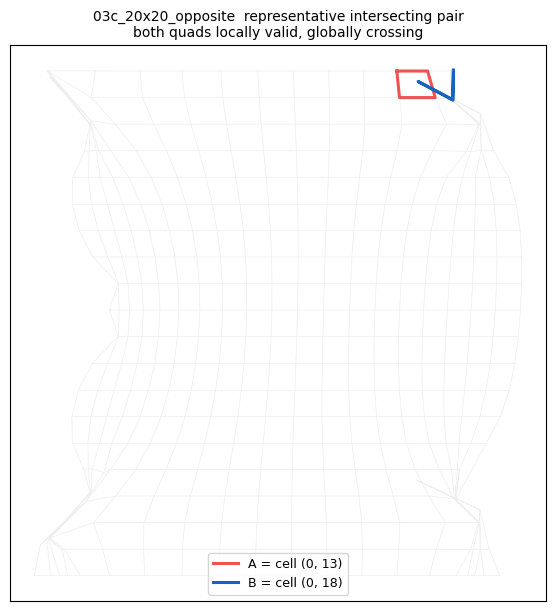

In [10]:
def plot_pair(phi, pair, title):
    (ra, ca), (rb, cb) = pair
    Hh, Ww = phi[0].shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + phi[1]; gy = yy + phi[0]
    fig, ax = plt.subplots(figsize=(9, 6), layout='constrained')
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#ededed', lw=0.5)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#ededed', lw=0.5)
    for (cy, cx), col, tag in [((ra, ca), '#ef5350', f'A = cell ({ra}, {ca})'),
                                ((rb, cb), '#1565c0', f'B = cell ({rb}, {cb})')]:
        poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
        poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
        ax.plot(poly_x, poly_y, color=col, lw=2.2, label=tag)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()

if qi_out:
    plot_pair(phi_out, qi_out[0],
              f'{CASE_KEY}  representative intersecting pair' + NL + 'both quads locally valid, globally crossing')

### Close-up with neighborhood: is the local neighborhood locally invertible?

For each intersecting pair `(A, B)` we zoom to a bounding box covering both cells *plus a radius-2 ring of neighboring cells around each*. The two focus cells (A in red, B in blue) are filled to show their overlap. Neighborhood cells are drawn as outlines only: **dark blue if the 2-triangle check still flags them**, **faint gray if they're locally valid**. After the best 2-triangle SLSQP run, every neighborhood cell should be gray - confirming the local neighborhood is clean everywhere around the intersection point.

Each quad is split along its TR-BL diagonal (dashed) and the two triangles in A and B are annotated with their signed areas. All four must be `>= threshold` by construction (SLSQP convergence). The overlap area is computed via a Sutherland-Hodgman convex-polygon clip and printed in the panel title.

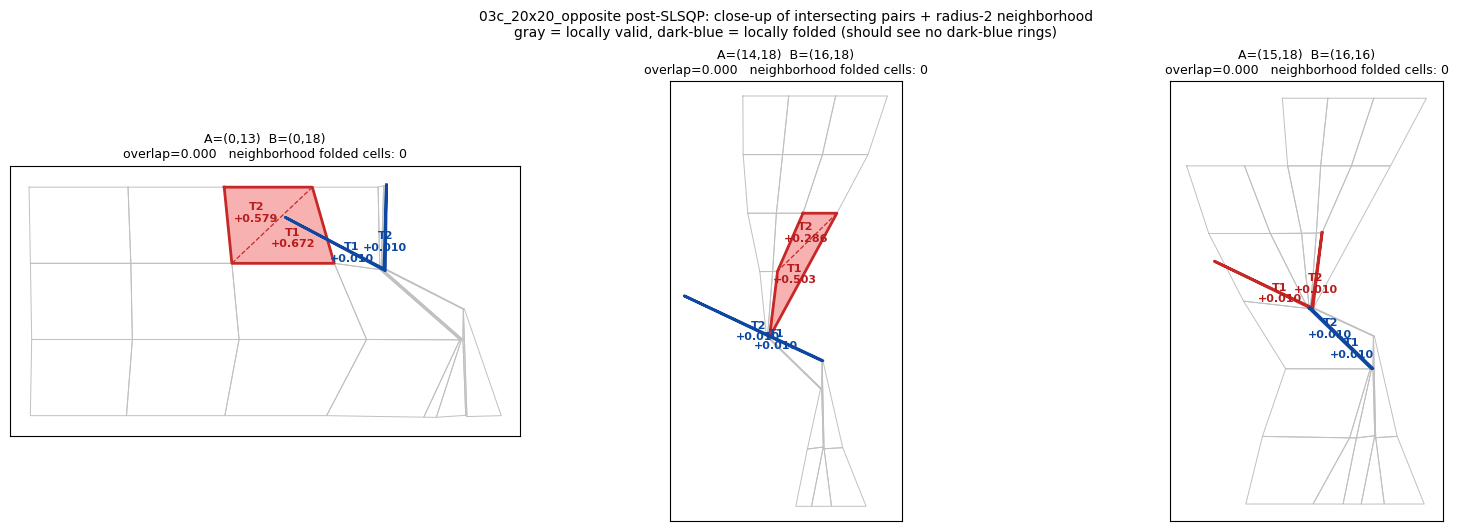

In [11]:
def _sutherland_hodgman(subject, clip):
    def inside(p, a, b):
        return (b[0] - a[0]) * (p[1] - a[1]) - (b[1] - a[1]) * (p[0] - a[0])
    def intersect(p1, p2, a, b):
        dx1, dy1 = p2[0] - p1[0], p2[1] - p1[1]
        dx2, dy2 = b[0]  - a[0],  b[1]  - a[1]
        denom = dx1 * dy2 - dy1 * dx2
        if denom == 0:
            return p2
        t = ((a[0] - p1[0]) * dy2 - (a[1] - p1[1]) * dx2) / denom
        return (p1[0] + t * dx1, p1[1] + t * dy1)
    def orientation(poly):
        s = 0.0
        for i in range(len(poly)):
            x1, y1 = poly[i]; x2, y2 = poly[(i + 1) % len(poly)]
            s += (x2 - x1) * (y2 + y1)
        return s
    if orientation(clip) > 0:     clip = list(reversed(clip))
    if orientation(subject) > 0:  subject = list(reversed(subject))
    output = list(subject)
    for i in range(len(clip)):
        if not output:
            break
        A, B = clip[i], clip[(i + 1) % len(clip)]
        inp = output; output = []
        for j in range(len(inp)):
            P = inp[j]; Q = inp[(j + 1) % len(inp)]
            p_in = inside(P, A, B) >= 0; q_in = inside(Q, A, B) >= 0
            if p_in:
                output.append(P)
                if not q_in:
                    output.append(intersect(P, Q, A, B))
            elif q_in:
                output.append(intersect(P, Q, A, B))
    return output

def _polygon_area(poly):
    n = len(poly)
    if n < 3:
        return 0.0
    s = 0.0
    for i in range(n):
        x1, y1 = poly[i]; x2, y2 = poly[(i + 1) % n]
        s += x1 * y2 - x2 * y1
    return 0.5 * abs(s)


def close_up_pair(phi, pair, tri_signed, ax, neighborhood_radius=2):
    (ra, ca), (rb, cb) = pair
    Hh, Ww = phi[0].shape
    nr, nc = Hh - 1, Ww - 1
    gx = phi[1] + np.mgrid[:Hh, :Ww][1]
    gy = phi[0] + np.mgrid[:Hh, :Ww][0]
    local_fold_mask = (tri_signed.min(axis=0) <= 0)

    def quad(r, c):
        return [(gx[r, c],      gy[r, c]),
                (gx[r, c+1],    gy[r, c+1]),
                (gx[r+1, c+1],  gy[r+1, c+1]),
                (gx[r+1, c],    gy[r+1, c])]

    # Neighborhood = radius-N ring around both A and B.
    nbhd_cells = set()
    for (r, c) in [(ra, ca), (rb, cb)]:
        for dr in range(-neighborhood_radius, neighborhood_radius + 1):
            for dc in range(-neighborhood_radius, neighborhood_radius + 1):
                rr, cc = r + dr, c + dc
                if 0 <= rr < nr and 0 <= cc < nc:
                    nbhd_cells.add((rr, cc))
    nbhd_cells.discard((ra, ca)); nbhd_cells.discard((rb, cb))

    # Gather all vertex coords to compute close-up bounding box.
    all_pts = []
    for r, c in list(nbhd_cells) + [(ra, ca), (rb, cb)]:
        all_pts.extend(quad(r, c))
    pad = 0.25
    xlim = (min(p[0] for p in all_pts) - pad, max(p[0] for p in all_pts) + pad)
    ylim = (min(p[1] for p in all_pts) - pad, max(p[1] for p in all_pts) + pad)

    # Draw neighborhood cell outlines (gray for valid, dark blue for any local fold).
    n_nbhd_bad = 0
    for (r, c) in nbhd_cells:
        q = quad(r, c)
        loop = q + [q[0]]
        is_bad = bool(local_fold_mask[r, c])
        col = '#1565c0' if is_bad else '#c0c0c0'
        lw = 1.4 if is_bad else 0.7
        ax.plot([p[0] for p in loop], [p[1] for p in loop],
                color=col, lw=lw, zorder=2)
        if is_bad:
            n_nbhd_bad += 1

    # Focus pair: filled quads.
    qA = quad(ra, ca); qB = quad(rb, cb)
    ax.fill([p[0] for p in qA], [p[1] for p in qA], color='#ef5350', alpha=0.45, zorder=3)
    ax.fill([p[0] for p in qB], [p[1] for p in qB], color='#1565c0', alpha=0.45, zorder=3)
    for (poly, col) in [(qA, '#c62828'), (qB, '#0d47a1')]:
        loop = poly + [poly[0]]
        ax.plot([p[0] for p in loop], [p[1] for p in loop], color=col, lw=2.0, zorder=4)
        ax.plot([poly[1][0], poly[3][0]], [poly[1][1], poly[3][1]],
                color=col, lw=0.9, ls='--', zorder=4)

    # Triangle signed-area annotations (T1 = indices 1,3,2; T2 = indices 0,3,1).
    def centroid(quad_vs, idx):
        pts = [quad_vs[i] for i in idx]
        return (sum(p[0] for p in pts)/3, sum(p[1] for p in pts)/3)
    t1A, t2A = tri_signed[0, ra, ca], tri_signed[1, ra, ca]
    t1B, t2B = tri_signed[0, rb, cb], tri_signed[1, rb, cb]
    for (q, col, t1, t2) in [(qA, '#b71c1c', t1A, t2A), (qB, '#0d47a1', t1B, t2B)]:
        cT1 = centroid(q, [1, 3, 2]); cT2 = centroid(q, [0, 3, 1])
        ax.text(cT1[0], cT1[1], 'T1' + chr(10) + f'{t1:+.3f}',
                 ha='center', va='center', color=col, fontsize=8, fontweight='bold', zorder=5)
        ax.text(cT2[0], cT2[1], 'T2' + chr(10) + f'{t2:+.3f}',
                 ha='center', va='center', color=col, fontsize=8, fontweight='bold', zorder=5)

    # Overlap area via Sutherland-Hodgman
    overlap = _sutherland_hodgman(qA, qB)
    ov_area = _polygon_area(overlap)

    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.invert_yaxis(); ax.set_aspect('equal')
    title = (f'A=({ra},{ca})  B=({rb},{cb})' + chr(10) +
              f'overlap={ov_area:.3f}   neighborhood folded cells: {n_nbhd_bad}')
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return ov_area, n_nbhd_bad


# Pick three representative pairs across the fold
if len(qi_out) >= 3:
    picks = [qi_out[0], qi_out[len(qi_out) // 2], qi_out[-1]]
else:
    picks = qi_out[:]

tri_after = r['tri']
fig, axes = plt.subplots(1, len(picks), figsize=(5.2 * len(picks), 5.2), layout='constrained')
if len(picks) == 1:
    axes = [axes]
for ax, pair in zip(axes, picks):
    close_up_pair(phi_out, pair, tri_after, ax, neighborhood_radius=2)
plt.suptitle(f'{CASE_KEY} post-SLSQP: close-up of intersecting pairs + radius-2 neighborhood' + chr(10) +
              'gray = locally valid, dark-blue = locally folded (should see no dark-blue rings)',
              fontsize=10)
plt.show()

### Signed-area table across all intersecting pairs + neighborhood check

For every one of the intersecting pairs: the four signed triangle areas in the two cells, the computed overlap area, and the count of *neighborhood* cells (radius 2 around each of the two cells, i.e., up to ~48 surrounding cells) that are locally folded. The last column should read `0` on every row - confirming that each intersection happens in a region that is otherwise entirely locally invertible. The failure is strictly non-local.

In [12]:
threshold = THRESHOLD
tri_after = r['tri']
local_fold_mask = tri_after.min(axis=0) <= 0
nr_total, nc_total = local_fold_mask.shape

def _radius_count(r, c, radius=2):
    cells = set()
    for dr in range(-radius, radius + 1):
        for dc in range(-radius, radius + 1):
            rr, cc = r + dr, c + dc
            if 0 <= rr < nr_total and 0 <= cc < nc_total:
                cells.add((rr, cc))
    return cells

gx_full = phi_out[1] + np.mgrid[:phi_out[0].shape[0], :phi_out[0].shape[1]][1]
gy_full = phi_out[0] + np.mgrid[:phi_out[0].shape[0], :phi_out[0].shape[1]][0]

def _quad_pts(r_, c_):
    return [(gx_full[r_, c_],      gy_full[r_, c_]),
            (gx_full[r_, c_+1],    gy_full[r_, c_+1]),
            (gx_full[r_+1, c_+1],  gy_full[r_+1, c_+1]),
            (gx_full[r_+1, c_],    gy_full[r_+1, c_])]

print(f'threshold = {threshold}   (all four triangle areas below should be >= this)')
print()
hdr = (f"  {'pair':<24s}  {'T1_A':>7s}  {'T2_A':>7s}  {'T1_B':>7s}  {'T2_B':>7s}  "
        f"{'overlap':>8s}  {'nbhd_folds':>10s}")
print(hdr)
print('-' * len(hdr))

total_overlap = 0.0
min_tri_across = +np.inf
total_nbhd_bad = 0
for (a, b) in qi_out:
    t1a, t2a = tri_after[0, a[0], a[1]], tri_after[1, a[0], a[1]]
    t1b, t2b = tri_after[0, b[0], b[1]], tri_after[1, b[0], b[1]]
    qA = _quad_pts(*a); qB = _quad_pts(*b)
    oa = _polygon_area(_sutherland_hodgman(qA, qB))
    nbhd = _radius_count(a[0], a[1]) | _radius_count(b[0], b[1])
    nbhd.discard(a); nbhd.discard(b)
    n_bad = sum(1 for (rr, cc) in nbhd if local_fold_mask[rr, cc])
    total_overlap += oa
    total_nbhd_bad += n_bad
    min_tri_across = min(min_tri_across, t1a, t2a, t1b, t2b)
    print(f'  {str(a):>10s} <-> {str(b):>10s}  '
          f'{t1a:>+7.3f}  {t2a:>+7.3f}  {t1b:>+7.3f}  {t2b:>+7.3f}  '
          f'{oa:>8.3f}  {n_bad:>10d}')

print()
print(f'  min triangle signed area across all 4*{len(qi_out)} = {4*len(qi_out)} triangles in flagged pairs: {min_tri_across:+.4f}')
print(f'  -> all >= threshold ({threshold}) within FP tolerance: {min_tri_across >= threshold - 1e-9}')
print(f'  total neighborhood folded cells (summed across all pairs): {total_nbhd_bad}')
print(f'  total overlap area across {len(qi_out)} pairs: {total_overlap:.3f}')

threshold = 0.01   (all four triangle areas below should be >= this)

  pair                         T1_A     T2_A     T1_B     T2_B   overlap  nbhd_folds
------------------------------------------------------------------------------------
     (0, 13) <->    (0, 18)   +0.672   +0.579   +0.010   +0.010     0.000           0
     (0, 13) <->    (1, 18)   +0.672   +0.579   +0.010   +0.010     0.002           0
     (0, 14) <->    (0, 18)   +0.323   +0.432   +0.010   +0.010     0.000           0
     (0, 14) <->    (1, 18)   +0.323   +0.432   +0.010   +0.010     0.006           0
     (0, 15) <->    (0, 18)   +0.010   +0.040   +0.010   +0.010     0.000           0
     (0, 15) <->    (1, 18)   +0.010   +0.040   +0.010   +0.010     0.000           0
     (0, 16) <->    (0, 18)   +0.010   +0.010   +0.010   +0.010     0.000           0
     (0, 16) <->    (1, 18)   +0.010   +0.010   +0.010   +0.010     0.000           0
     (0, 18) <->    (1, 16)   +0.010   +0.010   +0.010   +0.010     0.00

## Damping experiment: how much of the correction can we apply?

Interpolate linearly between `phi_init` and `phi_out`:

    phi(alpha) = phi_init + alpha * (phi_out - phi_init)

At `alpha = 0` we have the uncorrected initial field (`neg_TR` large, `QI` large). At `alpha = 1` we have the SLSQP output (`neg_TR = 0`, `QI > 0`). Scan `alpha` across the interval to see the trajectory.

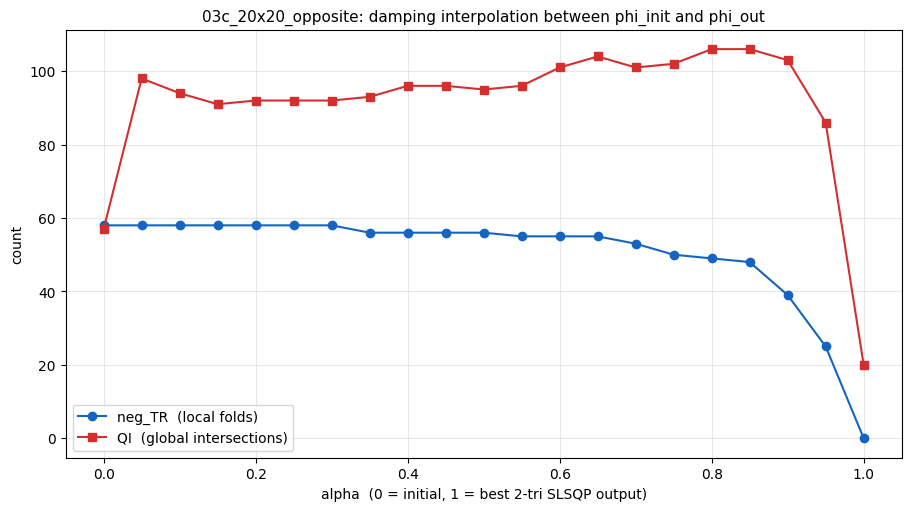


 alpha   neg_TR     QI
------------------------
  0.00       58     57
  0.05       58     98
  0.10       58     94
  0.15       58     91
  0.20       58     92
  0.25       58     92
  0.30       58     92
  0.35       56     93
  0.40       56     96
  0.45       56     96
  0.50       56     95
  0.55       55     96
  0.60       55    101
  0.65       55    104
  0.70       53    101
  0.75       50    102
  0.80       49    106
  0.85       48    106
  0.90       39    103
  0.95       25     86
  1.00        0     20


In [13]:
alphas = np.linspace(0.0, 1.0, 21)
tr_counts = []; qi_counts = []
for a in alphas:
    phi_a = phi_init + a * (phi_out - phi_init)
    m_a = measure(phi_a)
    qi_a = list_intersecting_quads(phi_a)
    tr_counts.append(m_a['n_tr'])
    qi_counts.append(len(qi_a))

fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')
ax.plot(alphas, tr_counts, 'o-', color='#1565c0', label='neg_TR  (local folds)')
ax.plot(alphas, qi_counts, 's-', color='#d32f2f', label='QI  (global intersections)')
ax.set_xlabel('alpha  (0 = initial, 1 = best 2-tri SLSQP output)')
ax.set_ylabel('count')
ax.set_title(f'{CASE_KEY}: damping interpolation between phi_init and phi_out', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.show()

# Print the trade-off table
print()
print(f"{'alpha':>6s}  {'neg_TR':>7s}  {'QI':>5s}")
print('-' * 24)
for a, tr, qi in zip(alphas, tr_counts, qi_counts):
    print(f'{a:>6.2f}  {tr:>7d}  {qi:>5d}')

## Summary and next steps

**What happened.**
`03c_20x20_opposite` has two regions with large displacements pointing *toward each other* (the 'opposite motion' pattern). Best 2-triangle SLSQP drives every cell's two triangles to at least `threshold`, so every cell is locally convex and `neg_TR = 0`. But the displacement pushed the two regions into each other, so quads from region A land on top of quads from region B in image space. Each cell is fine *in isolation*; the *map* is not injective.

**Why the 2-triangle constraint can't fix this.**
The constraint is per-cell. It sees three vertices at a time (per triangle) and evaluates one signed area. It has no way of knowing that two cells ten columns apart have their interiors overlapping. To catch that you need a non-local term - something that evaluates pairs of quads at a time.

**Damping trade-off** (from the scan above): reducing `alpha` below 1 re-introduces local folds faster than it removes global ones on this case, because the initial field is *also* heavily folded (large `neg_TR` at `alpha = 0`). So naive damping is not a good fix here - the two failure modes trade off linearly, not in our favor.

**Actual next steps** (from [03_demos.ipynb](03_demos.ipynb) 'next steps for global invertibility'):

1. **Outer-loop global constraint.** After 2-triangle SLSQP converges, call `list_intersecting_quads`. For each pair in the list, add a repulsion term to the objective (pair-specific signed-distance penalty) and re-solve. Each inner solve stays smooth; only the active pair set changes between outer iterations.
2. **Displacement damping toward identity** (not toward phi_init as tested above). Scale `phi_out` toward zero displacement until global intersections vanish. Guaranteed to succeed at `alpha = 0` but gives up all registration quality.
3. **Log-barrier on quad-pair signed distance** inside the L-BFGS barrier solver (`iterative_2d_barrier`). Expensive per-iteration but composes with the existing penalty pipeline.

Option 1 is the natural next implementation: cheap when pairs are empty, only pays the `O(n_quads^2)` cost when a genuine long-range crossing exists, and the pair list is already in hand after the inner SLSQP completes.